In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import xarray as xr
from scipy.stats import pearsonr

from sst_pix2pix_annual_cycle import Generator, rollout_prediction, get_seasonal_encoding
from train_cmip6_sst import denormalize_data, load_and_process_cmip6_data
from utils import save_rollout_to_netcdf_new,save_rollout_to_netcdf


In [2]:
# ============================================================================
# Load Trained Model
# ============================================================================

def load_trained_model(checkpoint_path, device='cpu'):
    """
    Load trained generator from checkpoint.
    
    Args:
        checkpoint_path: Path to checkpoint file
        device: 'cuda' or 'cpu'
    
    Returns:
        generator, climatology, norm_params, num_input_months
    """
    print(f"Loading checkpoint from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    num_input_months = checkpoint['num_input_months']
    in_channels = num_input_months + 2
    
    generator = Generator(in_channels=in_channels, features=128, out_channels=1).to(device)
    generator.load_state_dict(checkpoint['generator_state_dict'])
    generator.eval()
    
    climatology = checkpoint['climatology']
    norm_params = checkpoint['norm_params']
    
    print(f"Model loaded from epoch {checkpoint['epoch']}")
    if 'best_val_loss' in checkpoint:
        print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")
    
    return generator, climatology, norm_params, num_input_months



In [3]:
# ============================================================================
# Evaluation Functions
# ============================================================================

def evaluate_single_step(generator, test_data, test_months, num_input_months, 
                         climatology, norm_params, device='cpu'):
    """
    Evaluate single-step predictions on test set.
    
    Args:
        generator: trained generator
        test_data: test SST data (normalized)
        test_months: month indices
        num_input_months: number of input months
        climatology: monthly climatology
        norm_params: normalization parameters
        device: computation device
    
    Returns:
        metrics dictionary
    """
    from sst_pix2pix_annual_cycle import SSTDataset
    from torch.utils.data import DataLoader
    
    print("\n" + "="*70)
    print("Evaluating Single-Step Predictions")
    print("="*70)
    
    # Create test dataset
    test_dataset = SSTDataset(
        sst_data=test_data,
        months=test_months,
        num_input_months=num_input_months,
        climatology=climatology
    )
    
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    all_predictions = []
    all_targets = []
    all_months = []
    
    generator.eval()
    with torch.no_grad():
        for batch in test_loader:
            inputs = batch['input'].to(device)
            targets = batch['target'].to(device)
            target_months = batch['target_month']
            
            predictions = generator(inputs)
            
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
            all_months.extend(target_months.numpy())
    
    # Concatenate all predictions
    predictions = np.concatenate(all_predictions, axis=0).squeeze(1)  # (N, 48, 144)
    targets = np.concatenate(all_targets, axis=0).squeeze(1)
    all_months = np.array(all_months)
    
    # Denormalize
    predictions = denormalize_data(predictions, norm_params)
    targets = denormalize_data(targets, norm_params)
    
    # Compute metrics
    mae = np.mean(np.abs(predictions - targets))
    rmse = np.sqrt(np.mean((predictions - targets) ** 2))
    
    # Month-wise metrics
    month_mae = []
    month_rmse = []
    for month in range(12):
        month_mask = all_months == month
        if month_mask.sum() > 0:
            month_pred = predictions[month_mask]
            month_target = targets[month_mask]
            month_mae.append(np.mean(np.abs(month_pred - month_target)))
            month_rmse.append(np.sqrt(np.mean((month_pred - month_target) ** 2)))
        else:
            month_mae.append(np.nan)
            month_rmse.append(np.nan)
    
    print(f"\nOverall Metrics:")
    print(f"  MAE:  {mae:.4f} K")
    print(f"  RMSE: {rmse:.4f} K")
    
    print(f"\nMonth-wise RMSE:")
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    for i, (name, val) in enumerate(zip(month_names, month_rmse)):
        if not np.isnan(val):
            print(f"  {name}: {val:.4f} K")
    
    metrics = {
        'mae': mae,
        'rmse': rmse,
        'month_mae': month_mae,
        'month_rmse': month_rmse,
        'predictions': predictions,
        'targets': targets,
        'months': all_months
    }
    
    return metrics


def evaluate_rollout(generator, test_data, test_months, num_input_months, 
                     climatology, norm_params, num_rollout_months=24, 
                     num_rollouts=10, device='cuda'):
    """
    Evaluate multi-month rollout predictions.
    
    Args:
        generator: trained generator
        test_data: test SST data (normalized)
        test_months: month indices
        num_input_months: number of input months
        climatology: monthly climatology
        norm_params: normalization parameters
        num_rollout_months: how many months to predict
        num_rollouts: how many different starting points to test
        device: computation device
    
    Returns:
        rollout results and metrics
    """
    print("\n" + "="*70)
    print(f"Evaluating {num_rollout_months}-Month Rollout Predictions")
    print("="*70)
    
    all_rollout_predictions = []
    all_rollout_targets = []
    
    print("length of test data: "+str(len(test_data)))

    # Perform multiple rollouts from different starting points
    step_size = max(1, (len(test_data) - num_input_months - num_rollout_months) // num_rollouts)
    
    for i in range(num_rollouts):
        start_idx = num_input_months + i * step_size
        
        if start_idx + num_rollout_months >= len(test_data):
            break
        
        # Get initial inputs
        initial_inputs = torch.FloatTensor(test_data[start_idx-num_input_months:start_idx])
        initial_month = test_months[start_idx - 1]

        print(f"\nRollout {i+1}/{num_rollouts} - Starting month index: {start_idx}, month: {initial_month}")
        
        # Perform rollout
        predictions = rollout_prediction(
            generator, initial_inputs, initial_month, 
            num_months=num_rollout_months
        )
        
        # Get ground truth
        targets = test_data[start_idx:start_idx+num_rollout_months]
        
        all_rollout_predictions.append(np.array(predictions))
        all_rollout_targets.append(targets)
    
    # Convert to arrays
    rollout_predictions = np.array(all_rollout_predictions)  # (num_rollouts, num_months, 48, 144)
    rollout_targets = np.array(all_rollout_targets)
    
    # Denormalize
    rollout_predictions = denormalize_data(rollout_predictions, norm_params)
    rollout_targets = denormalize_data(rollout_targets, norm_params)
    
    # Compute metrics over time
    rollout_mae_vs_time = []
    rollout_rmse_vs_time = []
    print('Roll-out shape: '+str(rollout_predictions.shape))
    for t in range(num_rollout_months):
        mae_t = np.nanmean(np.abs(rollout_predictions[:, t] - rollout_targets[:, t]))
        rmse_t = np.sqrt(np.nanmean((rollout_predictions[:, t] - rollout_targets[:, t]) ** 2))
        rollout_mae_vs_time.append(mae_t)
        rollout_rmse_vs_time.append(rmse_t)
    
    print(f"\nRollout RMSE over time:")
    for t in range(min(12, num_rollout_months)):
        print(f"  Month {t+1}: {rollout_rmse_vs_time[t]:.4f} K")
    
    # Check annual cycle preservation
    if num_rollout_months >= 24:
        year1_preds = rollout_predictions[:, 0:12].mean(axis=(0, 2, 3))
        year2_preds = rollout_predictions[:, 12:24].mean(axis=(0, 2, 3))
        cycle_correlation = pearsonr(year1_preds, year2_preds)[0]
        print(f"\nAnnual cycle consistency (year 1 vs year 2): {cycle_correlation:.4f}")
    
    results = {
        'predictions': rollout_predictions,
        'targets': rollout_targets,
        'mae_vs_time': rollout_mae_vs_time,
        'rmse_vs_time': rollout_rmse_vs_time
    }
    
    return results


def compare_with_climatology(predictions, targets, months, climatology, norm_params):
    """
    Compare predictions with climatology baseline.
    
    Args:
        predictions: model predictions (denormalized)
        targets: ground truth (denormalized)
        months: month indices
        climatology: monthly climatology (normalized)
        norm_params: normalization parameters
    """
    print("\n" + "="*70)
    print("Comparison with Climatology Baseline")
    print("="*70)
    
    # Denormalize climatology
    climatology_denorm = denormalize_data(climatology, norm_params)
    
    # Get climatology predictions for test months
    clim_predictions = np.array([climatology_denorm[m] for m in months])
    
    # Model metrics
    model_mae = np.mean(np.abs(predictions - targets))
    model_rmse = np.sqrt(np.mean((predictions - targets) ** 2))
    
    # Climatology metrics
    clim_mae = np.mean(np.abs(clim_predictions - targets))
    clim_rmse = np.sqrt(np.mean((clim_predictions - targets) ** 2))
    
    # Skill score
    skill_score = 1 - (model_rmse / clim_rmse)
    
    print(f"\nModel Performance:")
    print(f"  MAE:  {model_mae:.4f} K")
    print(f"  RMSE: {model_rmse:.4f} K")
    
    print(f"\nClimatology Baseline:")
    print(f"  MAE:  {clim_mae:.4f} K")
    print(f"  RMSE: {clim_rmse:.4f} K")
    
    print(f"\nSkill Score: {skill_score:.4f}")
    if skill_score > 0:
        print("✓ Model outperforms climatology!")
    else:
        print("✗ Model underperforms climatology")
    
    return skill_score


In [4]:
lon_sst=np.array([  0.      ,   2.493056,   4.986111,   7.479167,   9.972222,  12.465278,
        14.958333,  17.451389,  19.944444,  22.4375  ,  24.930556,  27.423611,
        29.916667,  32.409722,  34.902778,  37.395833,  39.888889,  42.381944,
        44.875   ,  47.368056,  49.861111,  52.354167,  54.847222,  57.340278,
        59.833333,  62.326389,  64.819444,  67.3125  ,  69.805556,  72.298611,
        74.791667,  77.284722,  79.777778,  82.270833,  84.763889,  87.256944,
        89.75    ,  92.243056,  94.736111,  97.229167,  99.722222, 102.215278,
       104.708333, 107.201389, 109.694444, 112.1875  , 114.680556, 117.173611,
       119.666667, 122.159722, 124.652778, 127.145833, 129.638889, 132.131944,
       134.625   , 137.118056, 139.611111, 142.104167, 144.597222, 147.090278,
       149.583333, 152.076389, 154.569444, 157.0625  , 159.555556, 162.048611,
       164.541667, 167.034722, 169.527778, 172.020833, 174.513889, 177.006944,
       179.5     , 181.993056, 184.486111, 186.979167, 189.472222, 191.965278,
       194.458333, 196.951389, 199.444444, 201.9375  , 204.430556, 206.923611,
       209.416667, 211.909722, 214.402778, 216.895833, 219.388889, 221.881944,
       224.375   , 226.868056, 229.361111, 231.854167, 234.347222, 236.840278,
       239.333333, 241.826389, 244.319444, 246.8125  , 249.305556, 251.798611,
       254.291667, 256.784722, 259.277778, 261.770833, 264.263889, 266.756944,
       269.25    , 271.743056, 274.236111, 276.729167, 279.222222, 281.715278,
       284.208333, 286.701389, 289.194444, 291.6875  , 294.180556, 296.673611,
       299.166667, 301.659722, 304.152778, 306.645833, 309.138889, 311.631944,
       314.125   , 316.618056, 319.111111, 321.604167, 324.097222, 326.590278,
       329.083333, 331.576389, 334.069444, 336.5625  , 339.055556, 341.548611,
       344.041667, 346.534722, 349.027778, 351.520833, 354.013889, 356.506944])

lat_sst=np.array([-8.950000e+01, -8.577083e+01, -8.204167e+01, -7.831250e+01,
       -7.458333e+01, -7.085417e+01, -6.712500e+01, -6.339583e+01,
       -5.966667e+01, -5.593750e+01, -5.220833e+01, -4.847917e+01,
       -4.475000e+01, -4.102083e+01, -3.729167e+01, -3.356250e+01,
       -2.983333e+01, -2.610417e+01, -2.237500e+01, -1.864583e+01,
       -1.491667e+01, -1.118750e+01, -7.458333e+00, -3.729167e+00,
        1.136868e-13,  3.729167e+00,  7.458333e+00,  1.118750e+01,
        1.491667e+01,  1.864583e+01,  2.237500e+01,  2.610417e+01,
        2.983333e+01,  3.356250e+01,  3.729167e+01,  4.102083e+01,
        4.475000e+01,  4.847917e+01,  5.220833e+01,  5.593750e+01,
        5.966667e+01,  6.339583e+01,  6.712500e+01,  7.085417e+01,
        7.458333e+01,  7.831250e+01,  8.204167e+01,  8.577083e+01])

In [5]:
#!pip install basemap
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
def plot_map(lon,lat,data,file_name):
#     m = Basemap(projection='cyl', resolution='l',
#             llcrnrlat=np.min(lat), urcrnrlat=np.max(lat),
#             llcrnrlon=np.min(lon), urcrnrlon=np.max(lon), )

    m = Basemap(projection='cyl', resolution='l',
            llcrnrlat=np.min(lat_sst), urcrnrlat=np.max(lat_sst),
            llcrnrlon=np.min(lon_sst), urcrnrlon=np.max(lon_sst), )
    #m.drawcoastlines()
    #plt.show()
    lons,lats= np.meshgrid(lon,lat)
    x,y = m(lons,lats)
    
    #m.drawcoastlines()
    levels = np.linspace(min(np.unique(data)),max(np.unique(data)),21)
    #levels = np.linspace(0.0,1.0,21)
    #levels=[-30,-20,-12,-9,-6,-2,-1,+1,+2,+6,+9,+12,+20,+30]
    temp = m.contourf(x,y,data,levels=levels,cmap='seismic')
    cb = m.colorbar(temp,"bottom", size="15%", pad="10%")
    m.drawcoastlines()
    m.drawparallels(np.arange(-90., 91., 30.), labels=[1, 0, 0, 0])
    m.drawmeridians(np.arange(0., 361., 45.), labels=[0, 0, 0, 1])
    #plt.title('sst')
    #cb.set_label('sst')

    plt.savefig(file_name)
    


    plt.show()
    plt.clf()



In [6]:
# ============================================================================
# Visualization Functions
# ============================================================================

def plot_sample_predictions(predictions, targets, months, num_samples=6, 
                            save_path='sample_predictions.png'):
    """Plot sample predictions vs ground truth."""
    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 3*num_samples))
    
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Select random samples
    indices = np.random.choice(len(predictions), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        month_name = month_names[months[idx]]
        
        
        # Ground truth
        im1 = axes[i, 0].imshow(np.flip(targets[idx],axis=0), cmap='RdBu_r', aspect='auto')
        axes[i, 0].set_title(f'{month_name} - Ground Truth')
        axes[i, 0].axis('off')
        plt.colorbar(im1, ax=axes[i, 0], fraction=0.046)
        
        # Prediction
        im2 = axes[i, 1].imshow(np.flip(predictions[idx],axis=0), cmap='RdBu_r', aspect='auto')
        axes[i, 1].set_title(f'{month_name} - Prediction')
        axes[i, 1].axis('off')
        plt.colorbar(im2, ax=axes[i, 1], fraction=0.046)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Sample predictions saved to: {save_path}")
    plt.close()


def plot_rollout_comparison(rollout_results, start_month=0, 
                            save_path='rollout_comparison.png'):
    """Plot rollout predictions for a full year."""
    #predictions = rollout_results['predictions'][0, :12]  # First rollout, 12 months
    predictions = rollout_results['predictions'][0, :]  # First rollout, all months
    climatology=predictions.reshape(40, 12, 48, 144).mean(axis=0)
    print(rollout_results['predictions'].shape)
    #targets = rollout_results['targets'][0, :12]
    #targets = rollout_results['targets'][0, :].reshape(40, 12, 48, 144).mean(axis=0)
    
    # fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    
    # month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
    #                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # vmin = min(predictions.min(), targets.min())
    # vmax = max(predictions.max(), targets.max())
    
    # for i in range(12):
    #     row = i // 6
    #     col = i % 6
    #     month_idx = (start_month + i) % 12
        
    #     if row == 0:
    #         # Ground truth
    #         im = axes[row, col].imshow(np.flip(targets[i],axis=0), cmap='RdBu_r', aspect='auto', 
    #                                    vmin=vmin, vmax=vmax)
    #         axes[row, col].set_title(f'{month_names[month_idx]} (Truth)')
    #     else:
    #         # Prediction
    #         im = axes[row, col].imshow(np.flip(predictions[i],axis=0), cmap='RdBu_r', aspect='auto',
    #                                    vmin=vmin, vmax=vmax)
    #         axes[row, col].set_title(f'{month_names[month_idx]} (Pred)')
        
    #     axes[row, col].axis('off')
    
    # plt.tight_layout()
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # print(f"Rollout comparison saved to: {save_path}")
    # plt.close()
    for i in range(12):
        print('Month: '+str(i+1))
        plot_map(lon_sst,lat_sst,climatology[i],'../../Data/output/Temp/seasonal_pattern'+str(i+1)+'.png')


def plot_error_vs_lead_time(rollout_results, save_path='error_vs_leadtime.png'):
    """Plot how error grows with lead time."""
    mae_vs_time = rollout_results['mae_vs_time']
    rmse_vs_time = rollout_results['rmse_vs_time']
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    months = np.arange(1, len(mae_vs_time) + 1)
    ax.plot(months, rmse_vs_time, 'o-', label='RMSE', linewidth=2)
    ax.plot(months, mae_vs_time, 's-', label='MAE', linewidth=2)
    
    ax.set_xlabel('Lead Time (months)', fontsize=12)
    ax.set_ylabel('Error (K)', fontsize=12)
    ax.set_title('Prediction Error vs Lead Time', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Error vs lead time plot saved to: {save_path}")
    plt.close()


Loading checkpoint from: ./checkpoints_EC_Earth3_CC/best_model.pth


Model loaded from epoch 126
Best validation loss: 2.5961
Loading dataset from: ../../Data/CMIP6-SST/EC_Earth3_CC_historical_1850_2014.nc
Multiple ensembles found. Selecting ensemble 1
Data shape: (1980, 48, 144)
Data range: [-1.95, 34.73]
Mask shape: (48, 144)
Train shape: (1428, 48, 144)
Val shape: (100, 48, 144)
Test shape: (552, 48, 144)
Standardization - Mean: 9.4834, Std: 11.4823

Evaluating Single-Step Predictions


/home/deepayan/anaconda3/envs/test/lib/python3.9/site-packages/torch/nn/modules/conv.py:456: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at ../aten/src/ATen/native/Convolution.cpp:1040.)
  return F.conv2d(input, weight, bias, self.stride,



Overall Metrics:
  MAE:  0.3147 K
  RMSE: 0.5123 K

Month-wise RMSE:
  Jan: 0.5470 K
  Feb: 0.5321 K
  Mar: 0.4872 K
  Apr: 0.4667 K
  May: 0.4610 K
  Jun: 0.5130 K
  Jul: 0.5819 K
  Aug: 0.5981 K
  Sep: 0.5187 K
  Oct: 0.4617 K
  Nov: 0.4581 K
  Dec: 0.4986 K

Evaluating 480-Month Rollout Predictions
length of test data: 552

Rollout 1/1 - Starting month index: 3, month: 2
Roll-out shape: (1, 480, 48, 144)

Rollout RMSE over time:
  Month 1: 0.4443 K
  Month 2: 0.4777 K
  Month 3: 0.6091 K
  Month 4: 0.6307 K
  Month 5: 0.6054 K
  Month 6: 0.5513 K
  Month 7: 0.5539 K
  Month 8: 0.5893 K
  Month 9: 0.6086 K
  Month 10: 0.6664 K
  Month 11: 0.5994 K
  Month 12: 0.5690 K

Annual cycle consistency (year 1 vs year 2): 0.9974

Comparison with Climatology Baseline

Model Performance:
  MAE:  0.3147 K
  RMSE: 0.5123 K

Climatology Baseline:
  MAE:  0.4057 K
  RMSE: 0.7690 K

Skill Score: 0.3338
✓ Model outperforms climatology!

Generating visualizations...
Sample predictions saved to: sampl

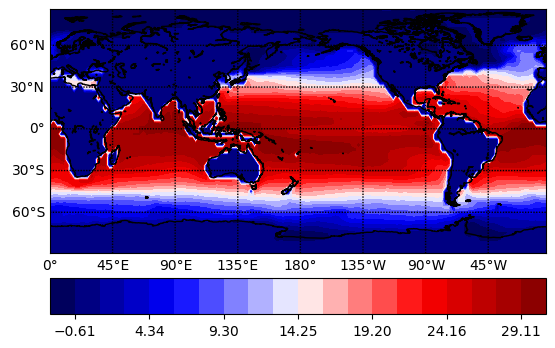

Month: 2


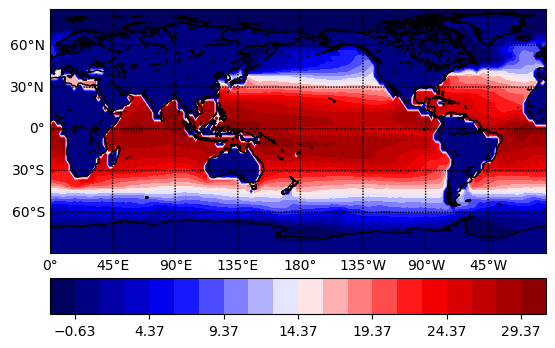

Month: 3


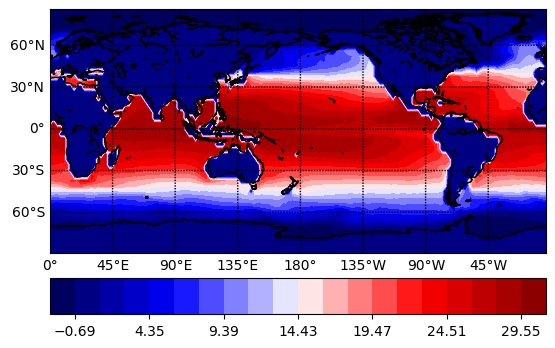

Month: 4


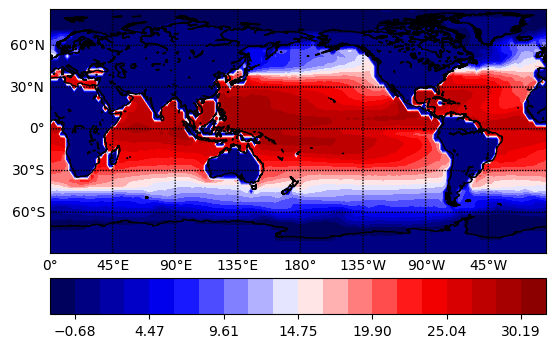

Month: 5


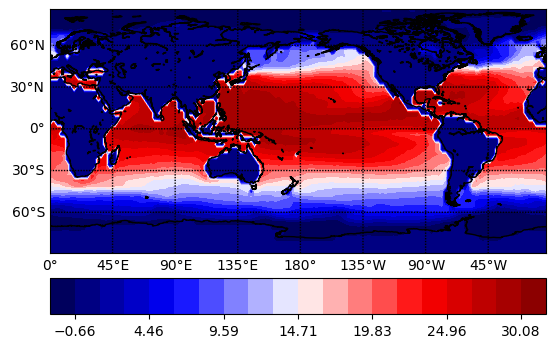

Month: 6


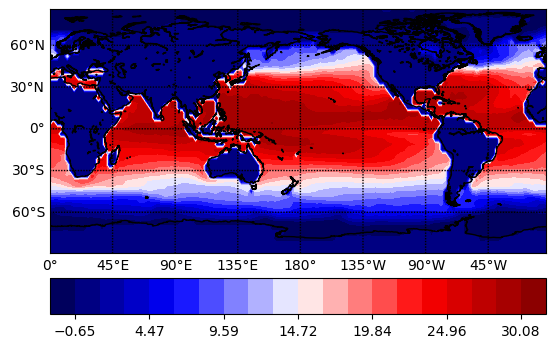

Month: 7


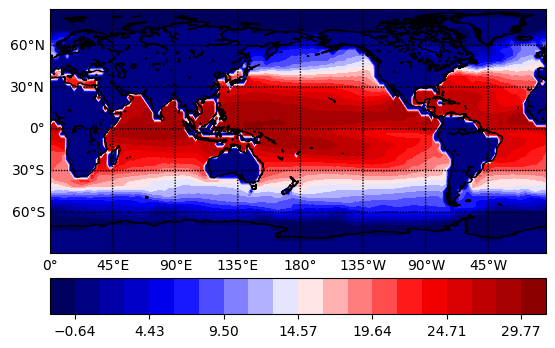

Month: 8


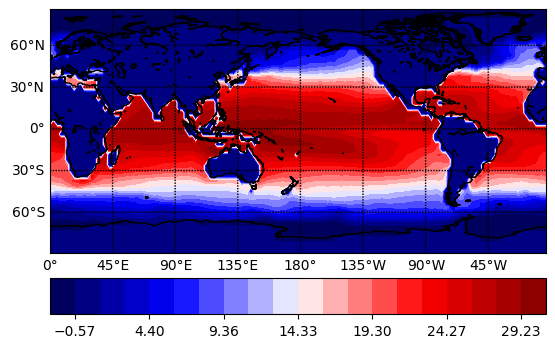

Month: 9


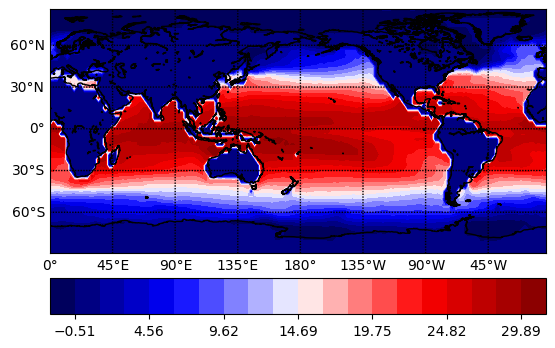

Month: 10


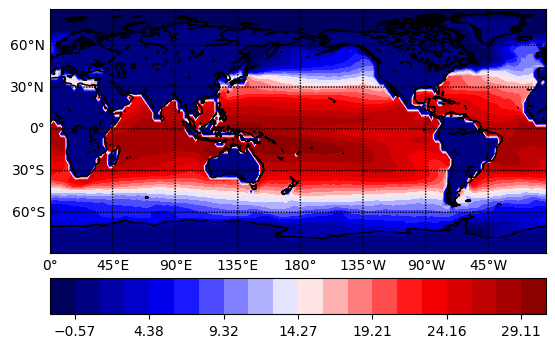

Month: 11


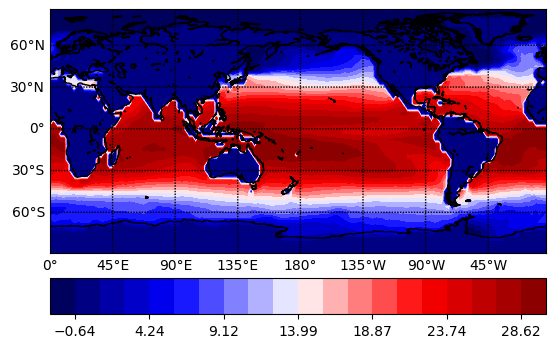

Month: 12


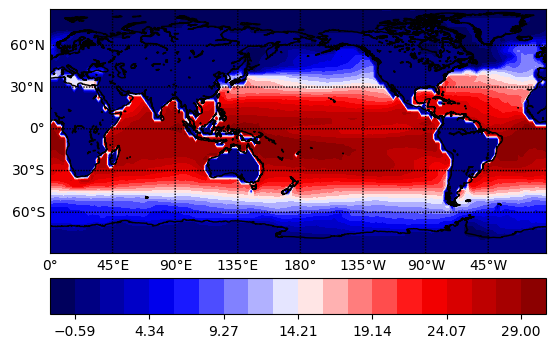

Error vs lead time plot saved to: error_vs_leadtime.png

Evaluation Complete!

Generated files:
  - sample_predictions.png
  - rollout_comparison.png
  - error_vs_leadtime.png


<Figure size 640x480 with 0 Axes>

In [7]:
# ============================================================================
# Main Test Script
# ============================================================================

# def main():
"""Main testing and evaluation script."""

# Configuration
CHECKPOINT_PATH = './checkpoints_EC_Earth3_CC/best_model.pth'
#DATASET_PATH = '../../Data/CMIP6-SST/GISS-E2-1-H_historical_1850_2014.nc'
#DATASET_PATH = '../../Data/CMIP6-SST/MIROC6_historical_1850_2014.nc'
DATASET_PATH = '../../Data/CMIP6-SST/EC_Earth3_CC_historical_1850_2014.nc'  
MASK_PATH = '../../Data/mask.npy'
N_TRAIN = 1428
N_VAL = 100
ENSEMBLE_ID = 1

device = 'cuda' #if torch.cuda.is_available() else 'cpu'

# Load model
generator, climatology, norm_params, num_input_months = load_trained_model(
    CHECKPOINT_PATH, device
)

# Load test data
_, _, test_data, _, _, test_months, mask = load_and_process_cmip6_data(
    DATASET_PATH, MASK_PATH, N_TRAIN, N_VAL, ENSEMBLE_ID
)

# Normalize test data with same parameters
from train_cmip6_sst import normalize_data
_, _, test_data_norm, _ = normalize_data(
    test_data, test_data, test_data, method=norm_params['method']
)

if norm_params['method'] == 'standardize':
    test_data_norm = (test_data - norm_params['mean']) / norm_params['std']
elif norm_params['method'] == 'minmax':
    test_data_norm = (test_data - norm_params['min']) / (norm_params['max'] - norm_params['min'])
else:
    test_data_norm = test_data

# 1. Single-step evaluation
metrics = evaluate_single_step(
    generator, test_data_norm, test_months, num_input_months,
    climatology, norm_params, device
)

# 2. Rollout evaluation
rollout_results = evaluate_rollout(
    generator, test_data_norm, test_months, num_input_months,
    climatology, norm_params, num_rollout_months=480, num_rollouts=1, device=device
)

# 3. Compare with climatology
skill_score = compare_with_climatology(
    metrics['predictions'], metrics['targets'], metrics['months'],
    climatology, norm_params
)

# 4. Visualizations
print("\nGenerating visualizations...")
plot_sample_predictions(metrics['predictions'], metrics['targets'], 
                        metrics['months'], num_samples=6)
plot_rollout_comparison(rollout_results)
plot_error_vs_lead_time(rollout_results)

print("\n" + "="*70)
print("Evaluation Complete!")
print("="*70)
print("\nGenerated files:")
print("  - sample_predictions.png")
print("  - rollout_comparison.png")
print("  - error_vs_leadtime.png")


In [11]:
# squeeze out the singleton rollout dimension
data = rollout_results['predictions'].squeeze()      # (time, lat, lon)
save_rollout_to_netcdf_new(data, lat_sst, lon_sst, '../../Data/output/EC_Earth3_CC/Updated/rollout_pred_ec_e1_full_50yrs.nc','1970-03-01')

written ../../Data/output/EC_Earth3_CC/Updated/rollout_pred_ec_e1_full_50yrs.nc  (480 time steps, 48 lat, 144 lon)


In [ ]:
save_rollout_to_netcdf(test_data, lat_sst, lon_sst, '../../Data/output/EC_Earth3_CC/Updated/EC_e1_model_data_full_raw.nc','1970-01-01')

written ../../Data/output/EC_Earth3_CC/Updated/EC_e1_model_data_full_raw.nc  (552 time steps, 48 lat, 144 lon)


: 

In [74]:
import xarray as xr
rollout = xr.open_dataset('../../Data/output/EC_Earth3_CC/Updated/rollout_pred_ec_e1_full_50yrs.nc')
ori_test = xr.open_dataset('../../Data/output/EC_Earth3_CC/Updated/EC_e1_model_data_full_raw.nc')

In [44]:
ori_test

<xarray.Dataset> Size: 31MB
Dimensions:  (time: 552, lat: 48, lon: 144)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1971-01-01 1971-02-01 ... 2016-12-01
  * lat      (lat) float64 384B -89.5 -85.77 -82.04 -78.31 ... 78.31 82.04 85.77
  * lon      (lon) float64 1kB 0.0 2.493 4.986 7.479 ... 349.0 351.5 354.0 356.5
Data variables:
    sst      (time, lat, lon) float64 31MB -0.8126 -0.8126 ... -0.9638 -0.9638

In [64]:
test_data.shape

(552, 48, 144)

Lat range: -89.5 to 85.77083
Lon range: 0.0 to 356.506944


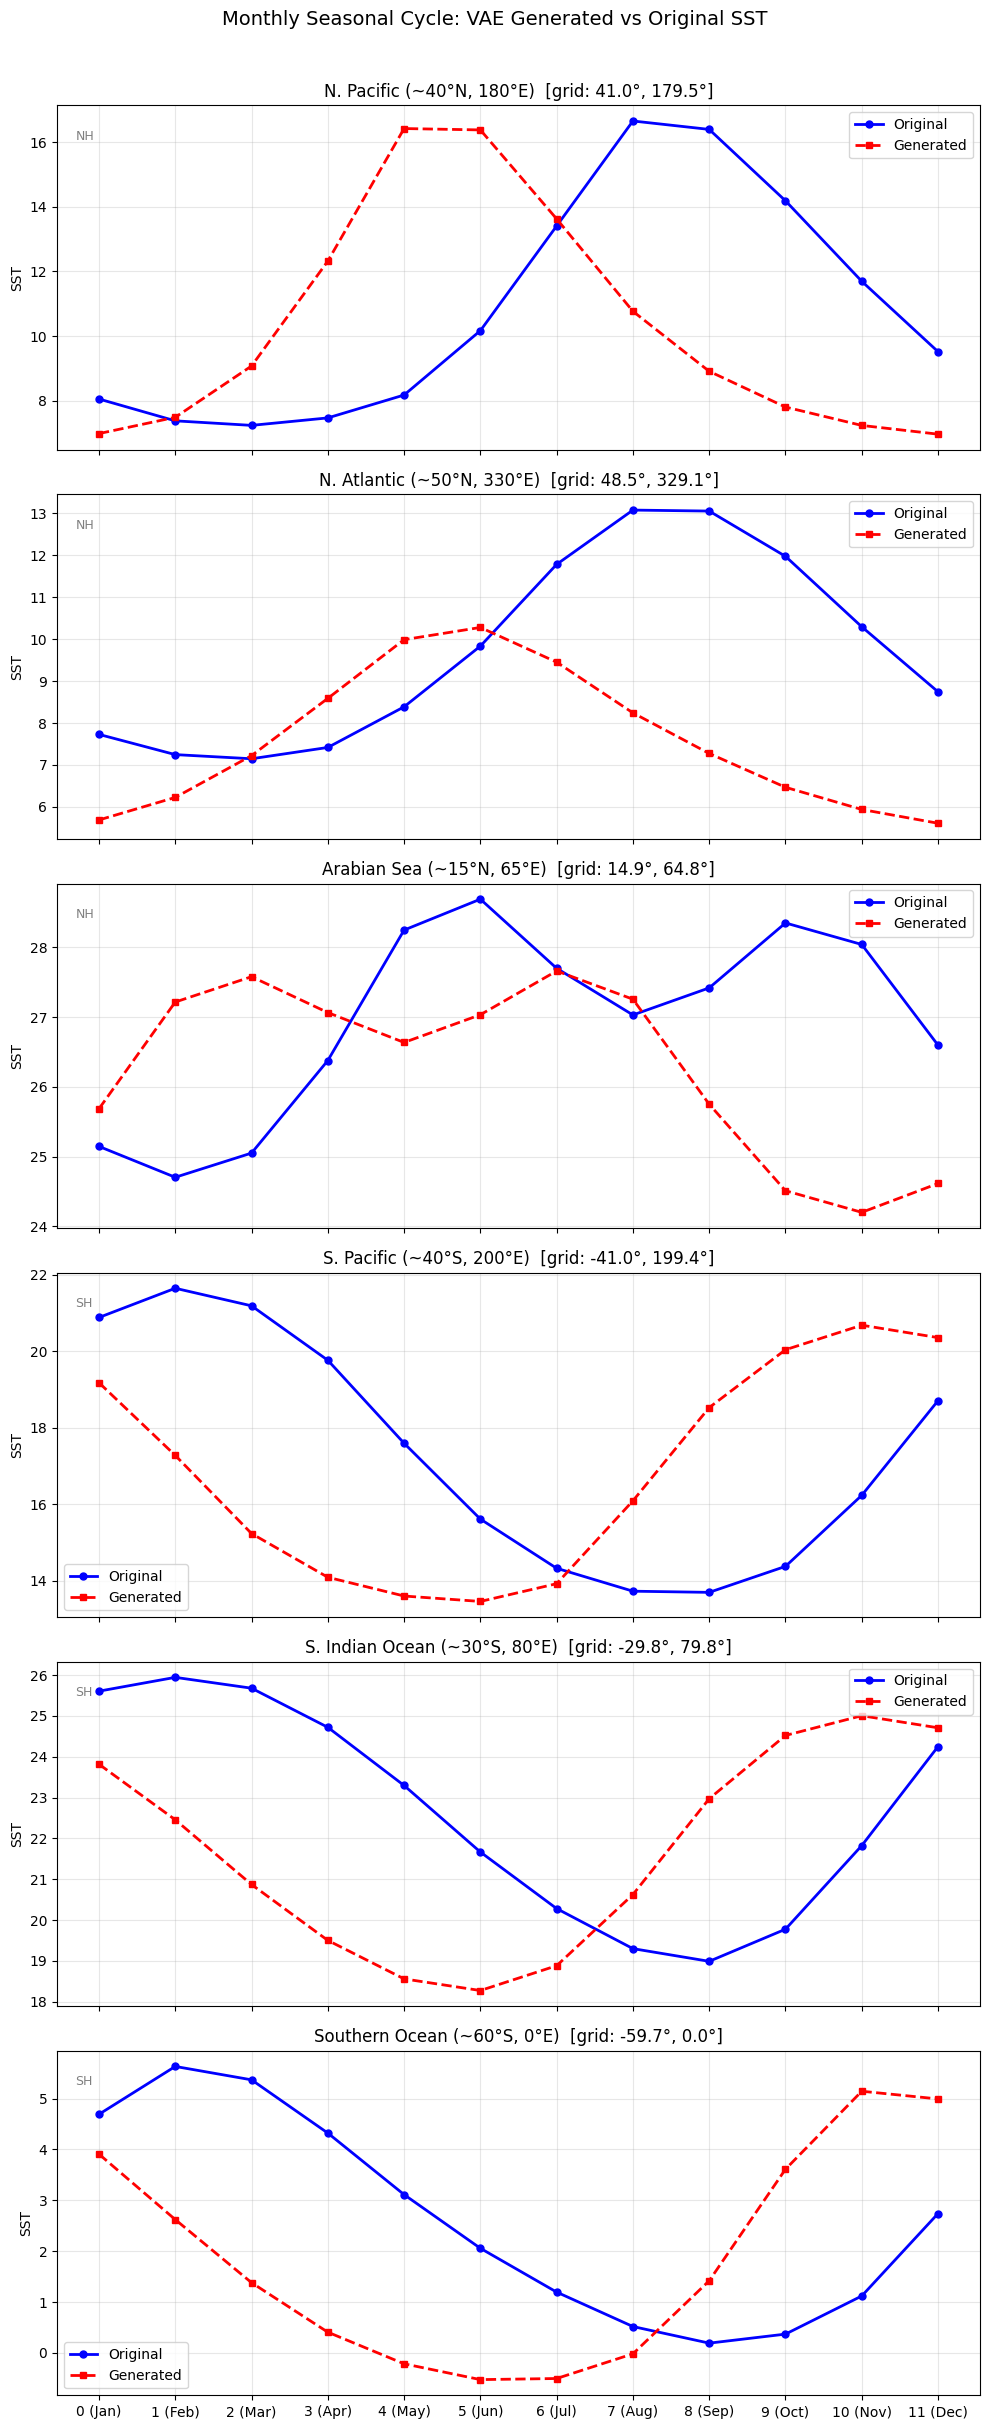

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

num_timesteps = test_data.shape[0]

# Calendar month for each time index (0=Jan, ..., 11=Dec)
months_for_each_t_ori = np.array(
    [(0 + t) % 12 for t in range(num_timesteps)]
)

num_timesteps = rollout_results['predictions'].squeeze().shape[0]
months_for_each_t_gen = np.array(
    [(0 + t) % 12 for t in range(num_timesteps)]
)

gen = rollout_results['predictions'].squeeze()   # (T, 48, 144)
ori = test_data         # (T, 48, 144)



print("Lat range:", lat_sst.min(), "to", lat_sst.max())
print("Lon range:", lon_sst.min(), "to", lon_sst.max())

def nearest_idx(arr, val):
    return int(np.argmin(np.abs(np.array(arr) - val)))

sample_locations = [

    ("N. Pacific (~40°N, 180°E)",    40,  180),
    ("N. Atlantic (~50°N, 330°E)",   50,  330),
    ("Arabian Sea (~15°N, 65°E)",    15,   65),

    ("S. Pacific (~40°S, 200°E)",   -40,  200),
    ("S. Indian Ocean (~30°S, 80°E)",-30,  80),
    ("Southern Ocean (~60°S, 0°E)", -60,    0),
]


month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

def monthly_climatology_at_point(data_T_lat_lon, lat_arr, lon_arr,
                                  months_array, target_lat, target_lon):
    """
    data_T_lat_lon : (T, 48, 144)
    months_array   : (T,) with values 0..11
    Returns        : (12,) mean SST for each calendar month
    """
    lat_i = nearest_idx(lat_arr, target_lat)
    lon_i = nearest_idx(lon_arr, target_lon)

    ts = data_T_lat_lon[:, lat_i, lon_i]   # (T,) time series at this point

    monthly_mean = np.zeros(12)
    for m in range(12):
        mask = (months_array == m)
        if mask.sum() > 0:
            monthly_mean[m] = ts[mask].mean()
        else:
            monthly_mean[m] = np.nan

    return monthly_mean


fig, axes = plt.subplots(
    nrows=len(sample_locations), ncols=1,
    figsize=(10, 4 * len(sample_locations)),
    sharex=True
)

x_ticks = np.arange(12)

for ax, (label, tlat, tlon) in zip(axes, sample_locations):

    gen_clim = monthly_climatology_at_point(
        gen, lat_sst, lon_sst, months_for_each_t_gen, tlat, tlon
    )
    ori_clim = monthly_climatology_at_point(
        ori, lat_sst, lon_sst, months_for_each_t_ori, tlat, tlon
    )


    lat_i = nearest_idx(lat_sst, tlat)
    lon_i = nearest_idx(lon_sst, tlon)
    actual_lat = float(np.array(lat_sst)[lat_i])
    actual_lon = float(np.array(lon_sst)[lon_i])

    ax.plot(x_ticks, ori_clim, 'b-o', label='Original',   linewidth=2, markersize=5)
    ax.plot(x_ticks, gen_clim, 'r--s', label='Generated', linewidth=2, markersize=5)

    ax.set_xticks(x_ticks)
    month_labels_with_idx = [f"{i} ({m})" for i, m in enumerate(month_labels)]
    ax.set_xticklabels(month_labels_with_idx)
    ax.set_ylabel("SST")
    ax.set_title(f"{label}  [grid: {actual_lat:.1f}°, {actual_lon:.1f}°]")
    ax.legend()
    ax.grid(True, alpha=0.3)


    if tlat > 0:
        ax.annotate("NH", xy=(0.02, 0.9),
                    xycoords='axes fraction', fontsize=9, color='gray')
    else:
        ax.annotate("SH", xy=(0.02, 0.9),
                    xycoords='axes fraction', fontsize=9, color='gray')

plt.suptitle("Monthly Seasonal Cycle: VAE Generated vs Original SST",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("seasonal_cycle_check.png", dpi=150, bbox_inches='tight')
plt.show()

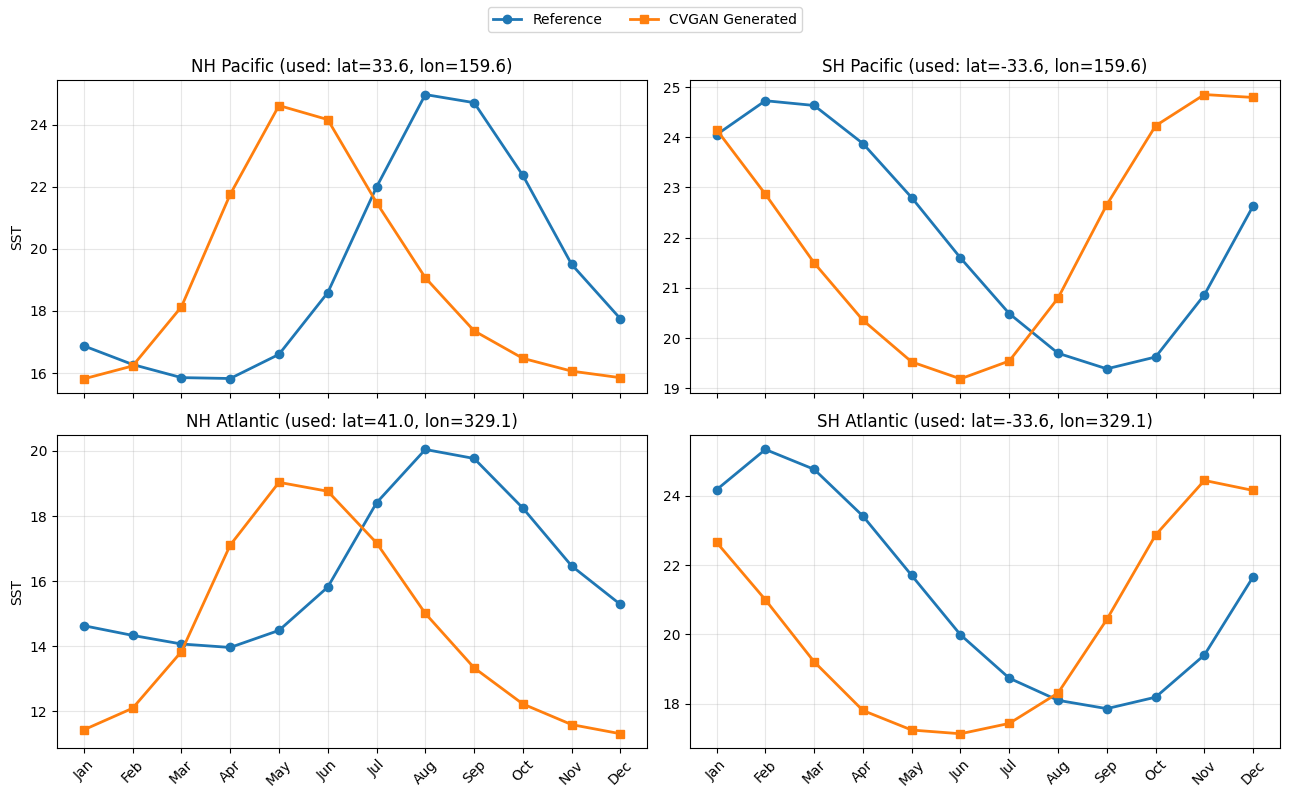

         point  lat_used    lon_used  ref_max_month  ref_min_month  \
0   NH Pacific  33.56250  159.555556              8              4   
1   SH Pacific -33.56250  159.555556              2              9   
2  NH Atlantic  41.02083  329.083333              8              4   
3  SH Atlantic -33.56250  329.083333              2              9   

   gen_max_month  gen_min_month  ref_peak_to_peak  gen_peak_to_peak  \
0              5              1          9.143696          8.800630   
1             11              6          5.344522          5.667271   
2              5             12          6.082650          7.723636   
3             11              6          7.471230          7.302261   

   shape_corr_12mo  
0        -0.118554  
1        -0.010162  
2        -0.044458  
3         0.025302  


In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def add_month_year_coords(ds, start_month0):
    ntime = ds.sizes["time"]
    month = ((start_month0 + np.arange(ntime)) % 12) + 1   # 1..12
    year_idx = np.arange(ntime) // 12
    return ds.assign_coords(
        month=("time", month),
        year_idx=("time", year_idx)
    )
start_month_test=0
vae_ds_m = add_month_year_coords(rollout, start_month_test)
ori_ds_m = add_month_year_coords(ori_test, start_month_test)

vae_clim = vae_ds_m["sst"].groupby("month").mean(dim=("time"), skipna=True)
ori_clim = ori_ds_m["sst"].groupby("month").mean(dim=("time"), skipna=True)


lon_vals = ori_test["lon"].values

def to_grid_lon(lon_query, lon_array):
    lon_min, lon_max = np.nanmin(lon_array), np.nanmax(lon_array)
    if lon_min >= 0 and lon_query < 0:            # grid is 0..360
        return lon_query % 360
    if lon_max <= 180 and lon_query > 180:        # grid is -180..180
        return ((lon_query + 180) % 360) - 180
    return lon_query


points = [
    {"name": "NH Pacific", "lat": 35.0,  "lon": 160.0},
    {"name": "SH Pacific", "lat": -35.0, "lon": 160.0},
    {"name": "NH Atlantic","lat": 40.0,  "lon": -30.0},
    {"name": "SH Atlantic","lat": -35.0, "lon": -30.0},
]

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
months = np.arange(1, 13)


fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
axes = axes.ravel()

summary_rows = []

def cycle_stats(arr):
    arr = np.asarray(arr, dtype=float)
    max_m = int(np.nanargmax(arr)) + 1
    min_m = int(np.nanargmin(arr)) + 1
    amp_pp = float(np.nanmax(arr) - np.nanmin(arr))
    return max_m, min_m, amp_pp

for ax, p in zip(axes, points):
    qlon = to_grid_lon(p["lon"], lon_vals)

    ref = ori_clim.sel(lat=p["lat"], lon=qlon, method="nearest")
    gen = vae_clim.sel(lat=p["lat"], lon=qlon, method="nearest")

    ref_vals = ref.values
    gen_vals = gen.values

    used_lat = float(ref["lat"].values)
    used_lon = float(ref["lon"].values)

    ax.plot(months, ref_vals, '-o', lw=2, label='Reference')
    ax.plot(months, gen_vals, '-s', lw=2, label='CVGAN Generated')
    ax.set_title(f'{p["name"]} (used: lat={used_lat:.1f}, lon={used_lon:.1f})')
    ax.set_xticks(months)
    ax.set_xticklabels(month_labels, rotation=45)
    ax.grid(alpha=0.3)

    # Metrics
    ref_max, ref_min, ref_amp = cycle_stats(ref_vals)
    gen_max, gen_min, gen_amp = cycle_stats(gen_vals)
    corr = float(np.corrcoef(ref_vals, gen_vals)[0, 1])

    summary_rows.append({
        "point": p["name"],
        "lat_used": used_lat,
        "lon_used": used_lon,
        "ref_max_month": ref_max,
        "ref_min_month": ref_min,
        "gen_max_month": gen_max,
        "gen_min_month": gen_min,
        "ref_peak_to_peak": ref_amp,
        "gen_peak_to_peak": gen_amp,
        "shape_corr_12mo": corr
    })

axes[0].set_ylabel("SST")
axes[2].set_ylabel("SST")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

summary_df = pd.DataFrame(summary_rows)
print(summary_df)

Generated


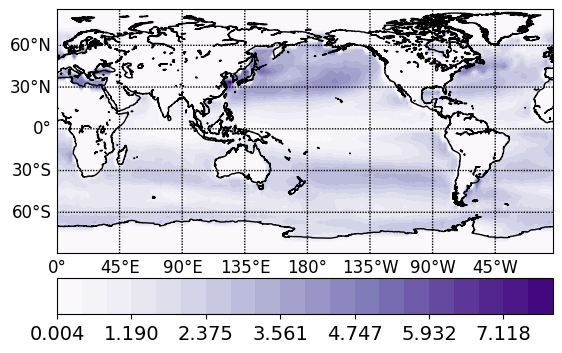

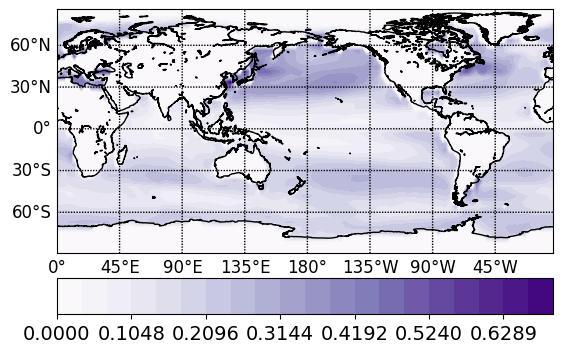

<Figure size 640x480 with 0 Axes>

In [12]:

def plot_map(lon,lat,data,file_name):
#     m = Basemap(projection='cyl', resolution='l',
#             llcrnrlat=np.min(lat), urcrnrlat=np.max(lat),
#             llcrnrlon=np.min(lon), urcrnrlon=np.max(lon), )

    m = Basemap(projection='cyl', resolution='l',
            llcrnrlat=np.min(lat_sst), urcrnrlat=np.max(lat_sst),
            llcrnrlon=np.min(lon_sst), urcrnrlon=np.max(lon_sst), )
    #m.drawcoastlines()
    #plt.show()
    lons,lats= np.meshgrid(lon,lat)
    x,y = m(lons,lats)
    
    #m.drawcoastlines()
    levels = np.linspace(min(np.unique(data)),max(np.unique(data)),21)
    #levels = np.linspace(0.0,7.0,11)
    #levels=[-30,-20,-12,-9,-6,-2,-1,+1,+2,+6,+9,+12,+20,+30]
    temp = m.contourf(x,y,data,levels=levels,cmap='Purples')
    cb = m.colorbar(temp,"bottom", size="15%", pad="10%")
    cb.ax.tick_params(labelsize=14)  # Increase font size of colorbar ticks
    m.drawcoastlines()
    m.drawparallels(np.arange(-90., 91., 30.), labels=[1, 0, 0, 0], fontsize=12)
    m.drawmeridians(np.arange(0., 361., 45.), labels=[0, 0, 0, 1], fontsize=12)
    #plt.title('sst')
    #cb.set_label('sst')

    plt.savefig(file_name,dpi=300,bbox_inches='tight')
    


    plt.show()
    plt.clf()

print('Generated')
plot_map(lon_sst,lat_sst,rollout_results['predictions'].squeeze().std(axis=0),'std.png')
plot_map(lon_sst,lat_sst,test_data_norm.std(axis=0),'std.png')

In [13]:
# -*- coding: utf-8 -*-
"""
Created on Sat Nov 20 22:18:26 2021

@author: Devabrat
"""

import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq
import pylab as pl
from scipy import signal
import matplotlib.pyplot as plt
import scipy.stats
from netCDF4 import Dataset

def cal_power_spect(data):
    #data=N_EP_gen#np.loadtxt('iod.txt', dtype=np.float32)
    #data=data_whole.variables['temp'][:]
    #data=data.reshape(data.shape[0],)

    nd=len(data)


    nrho=len(data)
    rho=0
    sommesup=0
    sommeinf=0
    for i in range(1,nrho):
        j=i-1
        sommesup=sommesup+(data[i]*data[j])
        sommeinf=sommeinf+((data[j]**2))

    rho=sommesup/sommeinf

    nt=len(data)

    rzero=0
    redtab=[]
    red=[]

    srho=np.sqrt(1-rho**2)

    nsim=1500

    red_sum=np.zeros((nd, nsim))
    for i in range(nsim):
    
        white=srho*np.random.randn(1)
        red_sum[0,i]=rho*rzero+white
        
        for j in range(1,nd):
            white=srho*np.random.randn(1)
            red_sum[j,i]=rho*red_sum[j-1,i]+white
            
    redtab.append(red_sum)
        
    redtab=np.array(redtab)
    redtab=redtab.reshape(nd,nsim)


    fs=1
    f, Po = signal.periodogram(data, fs, detrend='linear')

    npo=len(Po)
    Po=Po.reshape(npo,)

    Ax=np.sum(Po)/npo

    red2=[]
    specred=np.zeros((npo,nsim))

    for i in range(nsim):
        red2=redtab[:,i]
        red2m=np.sum(red2)/nd
        red2n=red2-red2m
        fs=1
        fr, Pr = signal.periodogram(red2n, fs, detrend='linear')  #detrend = linear
        npr=len(Pr)
        Pr=Pr.reshape(npr,)
        
        Ar=np.sum(Pr)/npr
        Pr=Pr*(Ax/Ar)
        specred[:,i]=Pr
        
    Mpr=0
    Mspecred=[]
    for i in range(npr):
        Mpr=specred[i,1]
        for j in range(1,nsim):
            Mpr=Mpr+specred[i,j]
        
        Mpr=np.sum(Mpr)/nsim
        Mspecred.append(Mpr)

    Mspecred=np.array(Mspecred)


    period_Po=1/f
    period_Pr=1/fr


    n85=round(1500*85/100)
    n90=round(1500*90/100)
    n95=round(1500*95/100)
    n99=round(1500*99/100)


    tabvecsort=np.zeros((npr,nsim))
    for i in range(npr):
        vec=specred[i,:]
        tabvecsort[i,:]=np.sort(vec)
        
    tabMC=np.zeros((npr,4))

    for i in range(npr):
        tabMC[i,0]=tabvecsort[i,n85]
        tabMC[i,1]=tabvecsort[i,n90]
        tabMC[i,2]=tabvecsort[i,n95]
        tabMC[i,3]=tabvecsort[i,n99]
        

        
    plot=np.zeros((Po.shape[0],3), dtype=np.float32)

    plot[:,0]=period_Po
    plot[:,1]=f*Po
    plot[:,2]=f*tabMC[:,2]
    return plot





Generated


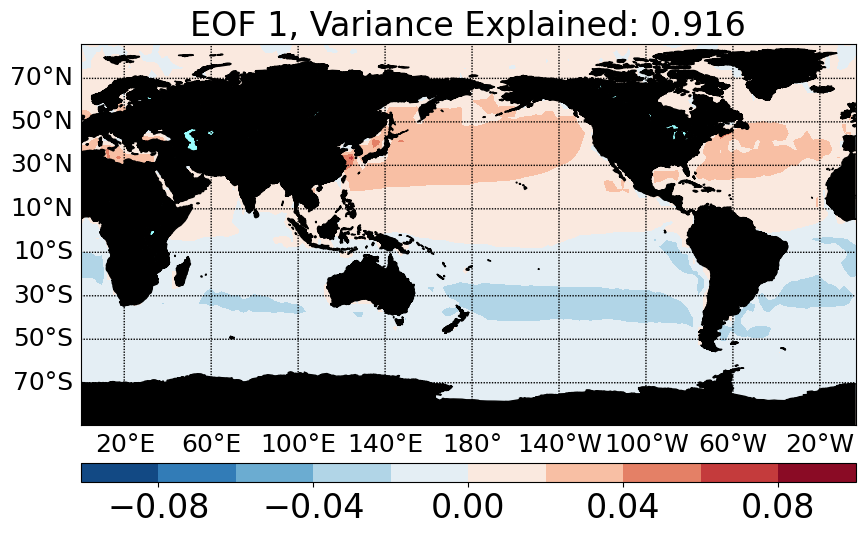

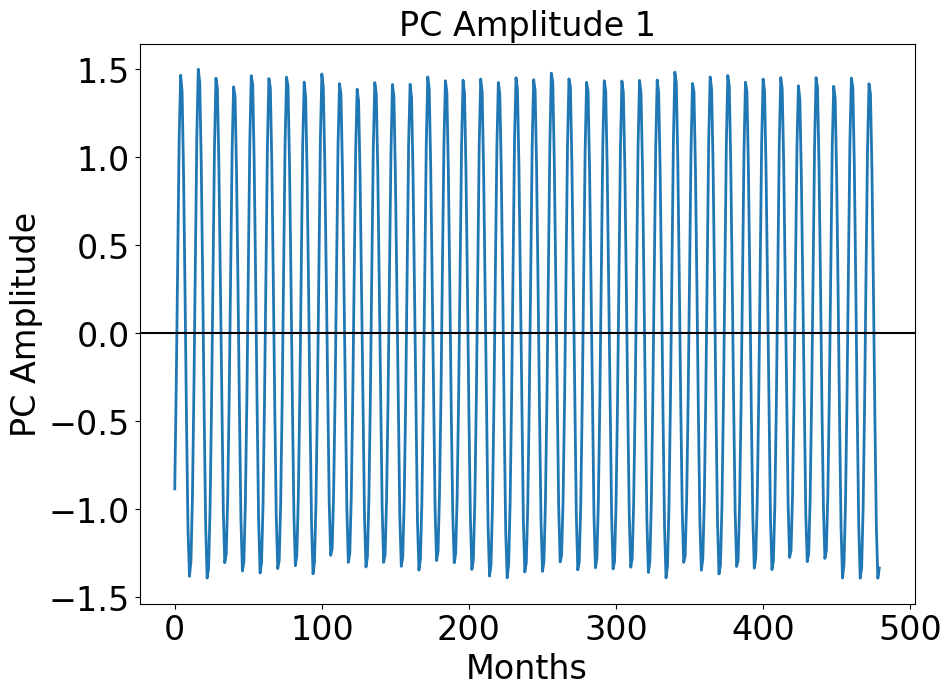

/tmp/ipykernel_1542594/3630853429.py:99: RuntimeWarning: divide by zero encountered in divide
  period_Po=1/f
/tmp/ipykernel_1542594/3630853429.py:100: RuntimeWarning: divide by zero encountered in divide
  period_Pr=1/fr


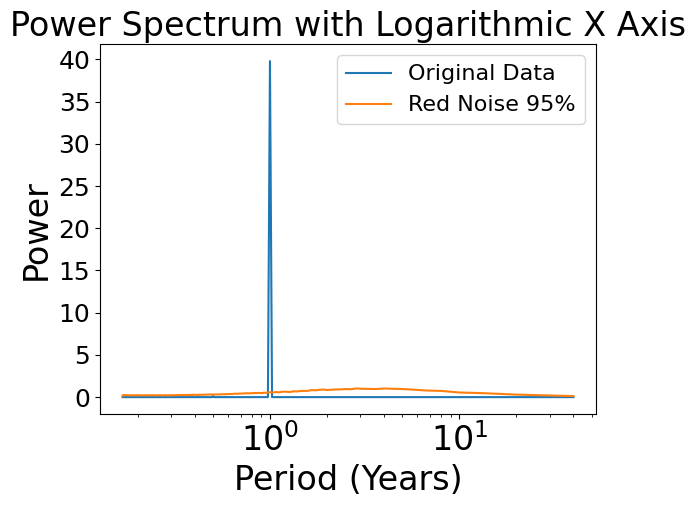

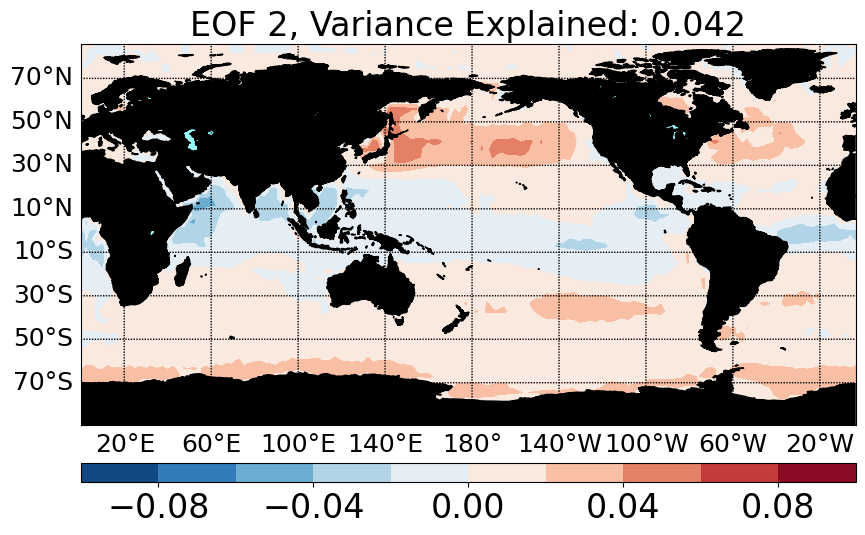

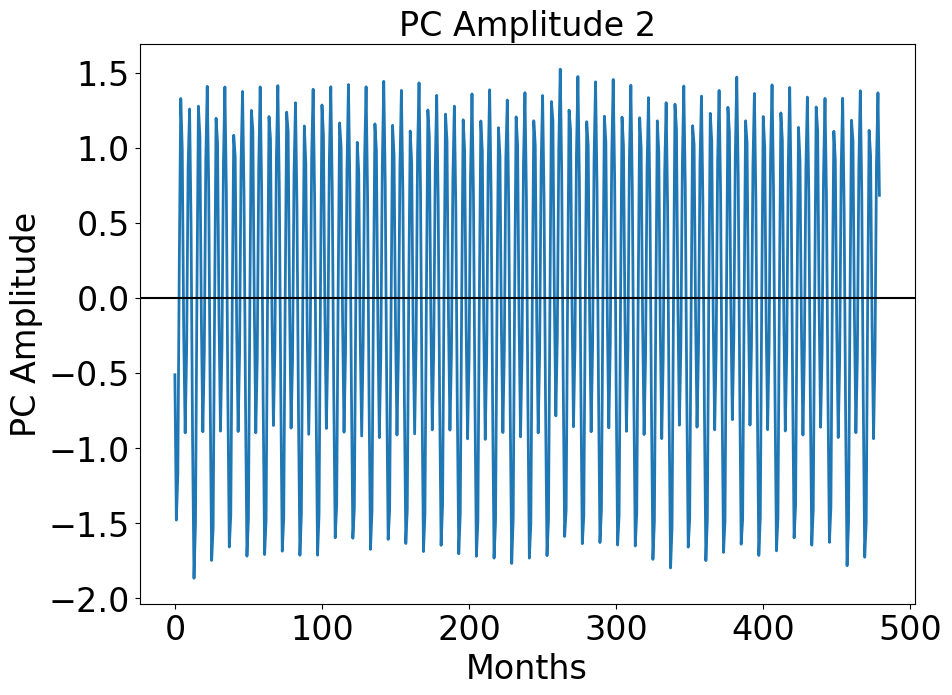

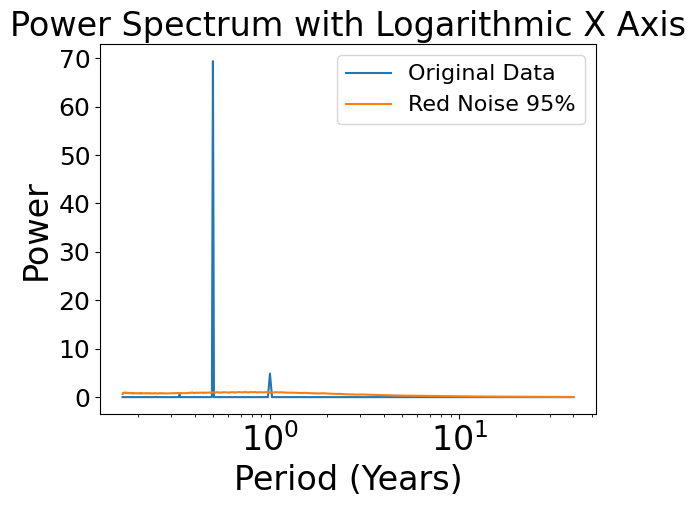

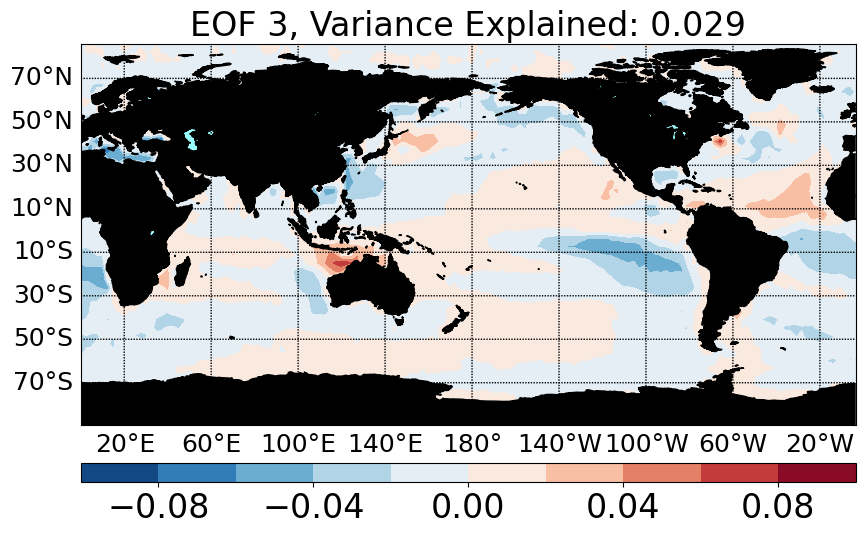

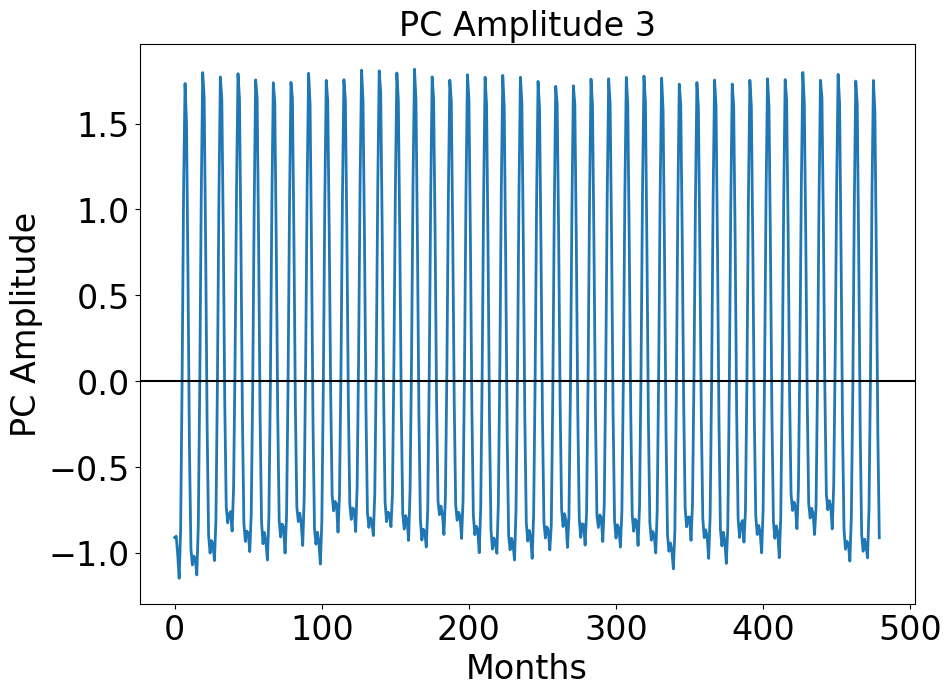

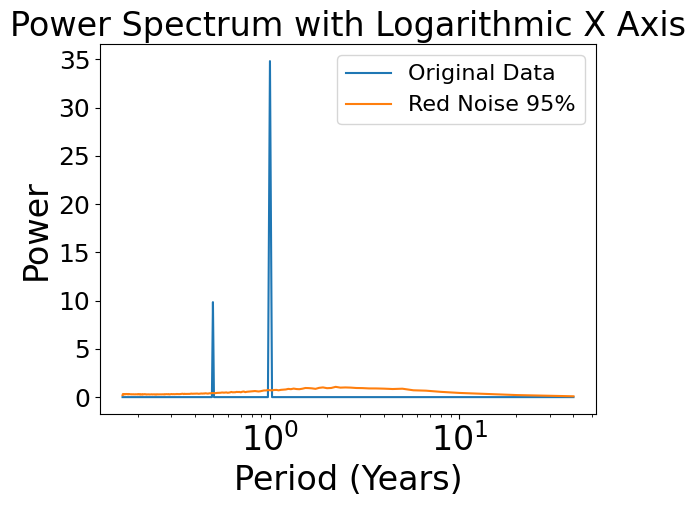

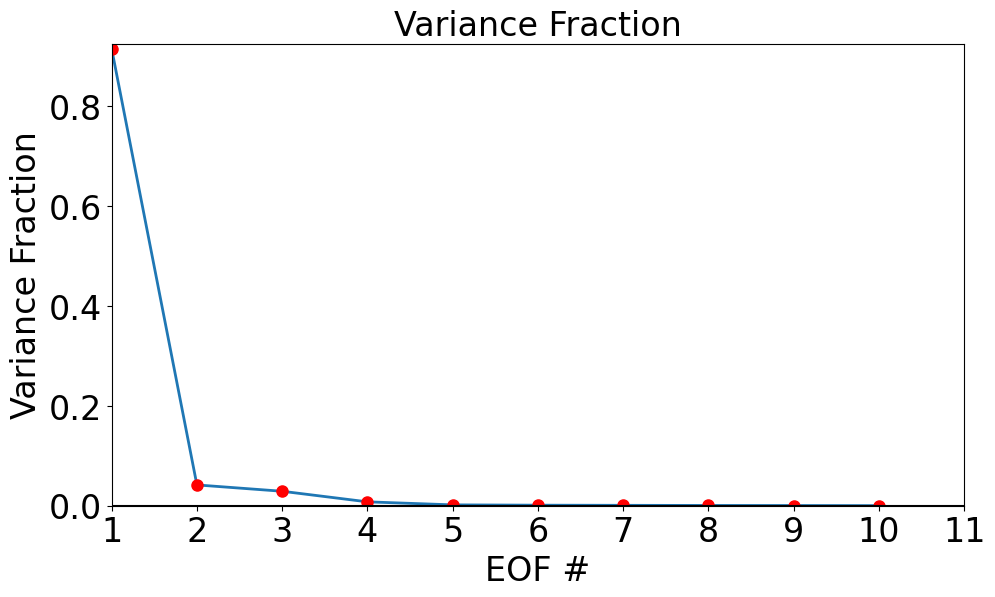

In [29]:
from eofs.standard import Eof
print('Generated')
lat = lat_sst
lon = lon_sst

# Remove all time steps where all values are NaN

sst_data = rollout_results['predictions'].reshape(-1,12,48,144) - climatology 
sst_data = sst_data.reshape(-1,48,144)
# Find time indices where not all values are NaN
valid_time_idx = ~np.all(np.isnan(sst_data), axis=(1, 2))
Data = sst_data[valid_time_idx]

wgts = np.cos(np.deg2rad(lat)).reshape(len(lat), 1)
coslat = np.cos(np.deg2rad(lat))
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(Data, weights=wgts)
eof1 = solver.eofs()

pc=solver.pcs(pcscaling=1)
varfrac=solver.varianceFraction()
lambdas=solver.eigenvalues()


parallels = np.arange(-90,90,20)
meridians = np.arange(-180,180,40)



for i in range(3):
    fig=plt.figure(figsize=(10,16)) 

    m=Basemap(projection='cyl', llcrnrlon=min(lon), llcrnrlat=min(lat),
            urcrnrlon=max(lon), urcrnrlat=max(lat), resolution='l')
    x, y = m(*np.meshgrid(lon,lat))
    clevs = np.linspace(-0.1,0.1,11)
    cs = m.contourf(x,y,eof1[i,:,:].squeeze(),clevs,cmap=plt.cm.RdBu_r)
    m.drawcoastlines()
    m.fillcontinents(color='#000000',lake_color='#99ffff')
    
    m.drawparallels(parallels,labels=[1,0,0,0], fontsize=18)
    m.drawmeridians(meridians,labels=[1,0,0,1], fontsize=18)

    cb=m.colorbar(cs, 'bottom', size='5%',pad='10%')
    cb.ax.tick_params(labelsize=24)  # Increase font size of colorbar ticks
    #cb.set_label('EOF', fontsize=10)
    plt.title('EOF '+str(i+1)+', Variance Explained: '+str(round(varfrac[i],3)), fontsize=24)  
    plt.savefig('temp.png',dpi=300,bbox_inches='tight')
    plt.show()
    fig=plt.figure(figsize=(10,16))
    plt.subplot(212)
    #days = pd.date_range('1871-01-01', '2011-01-01', freq='ME')
    plt.plot( pc[:,i], linewidth=2)
    plt.axhline(0, color='k')
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    plt.xlabel('Months', fontsize=24)
    plt.ylabel('PC Amplitude', fontsize=24) 
    plt.title('PC Amplitude '+str(i+1), fontsize=24)    
    plt.savefig('temp.png',dpi=300,bbox_inches='tight')
    plt.show()

    plot=cal_power_spect(pc[:,i])
    plt.plot(plot[:, 0]/ 12, plot[:, 1], label='Original Data')
    plt.plot(plot[:, 0]/ 12, plot[:, 2], label='Red Noise 95%')
    plt.xscale('log')
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=18)
    plt.xlabel('Period (Years)', fontsize=24)
    plt.ylabel('Power', fontsize=24)
    plt.legend(fontsize=16)
    plt.title('Power Spectrum with Logarithmic X Axis', fontsize=24)
    plt.savefig('temp.png',dpi=300,bbox_inches='tight')
    plt.show()

plt.figure(figsize=(11,6))
eof_num = range(1, 11)
plt.plot(eof_num, varfrac[0:10], linewidth=2)
plt.plot(eof_num, varfrac[0:10], linestyle='None', marker="o", color='r', markersize=8)
plt.axhline(0, color='k')
plt.xticks(range(1, 16),fontsize=24)
plt.yticks(fontsize=24)
plt.title('Fraction of the total variance represented by each EOF', fontsize=15)
plt.xlabel('EOF #', fontsize=24)
plt.ylabel('Variance Fraction', fontsize=24)
plt.xlim(1, 11)
plt.ylim(np.min(varfrac), np.max(varfrac)+0.01)
plt.title('Variance Fraction', fontsize=24)  
plt.savefig('temp.png',dpi=300,bbox_inches='tight')
plt.show()

In [16]:
from scipy.signal import detrend
test_data_norm_detrend = detrend(test_data_norm, axis=0)

In [27]:


(test_data_norm_detrend.reshape(-1,12,48,144) - climatology).shape

(46, 12, 48, 144)

test data


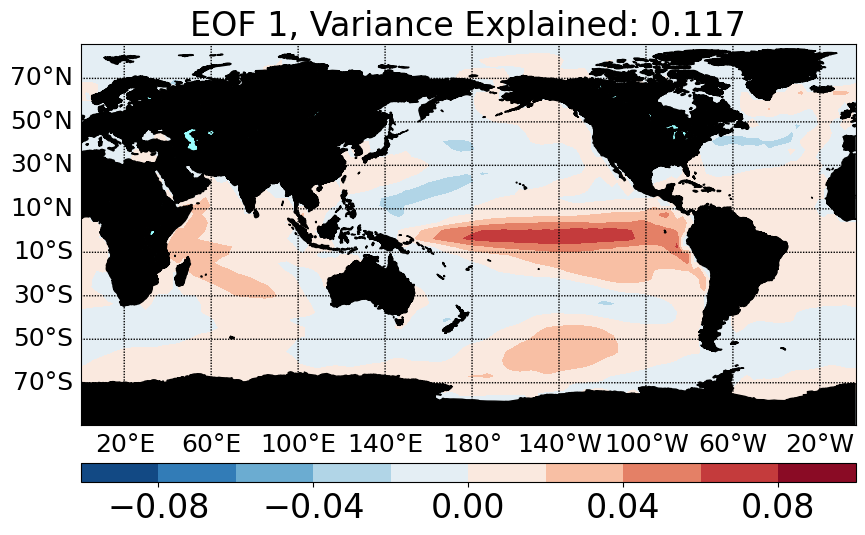

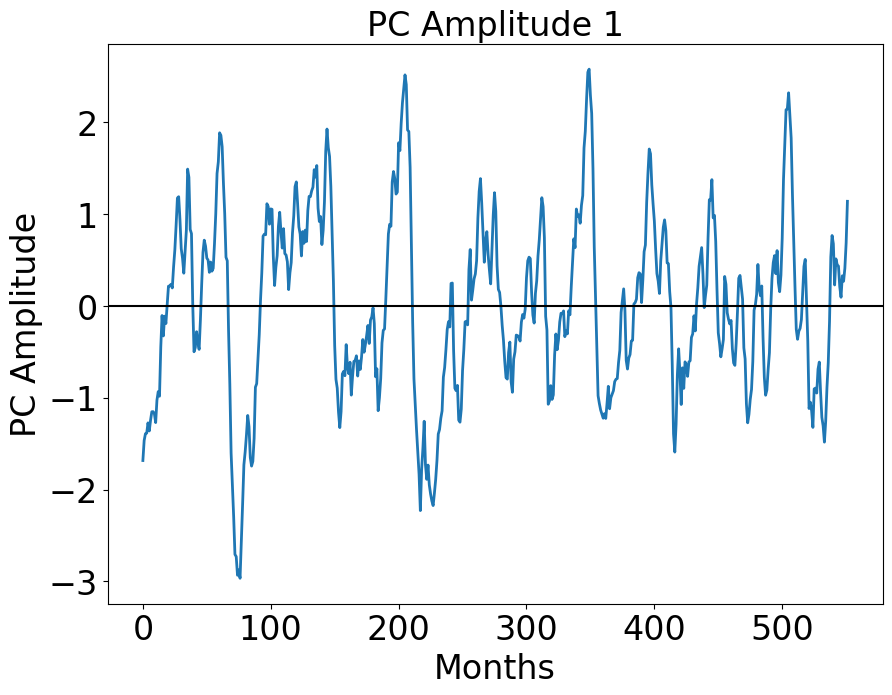

/tmp/ipykernel_1542594/3630853429.py:99: RuntimeWarning: divide by zero encountered in divide
  period_Po=1/f
/tmp/ipykernel_1542594/3630853429.py:100: RuntimeWarning: divide by zero encountered in divide
  period_Pr=1/fr


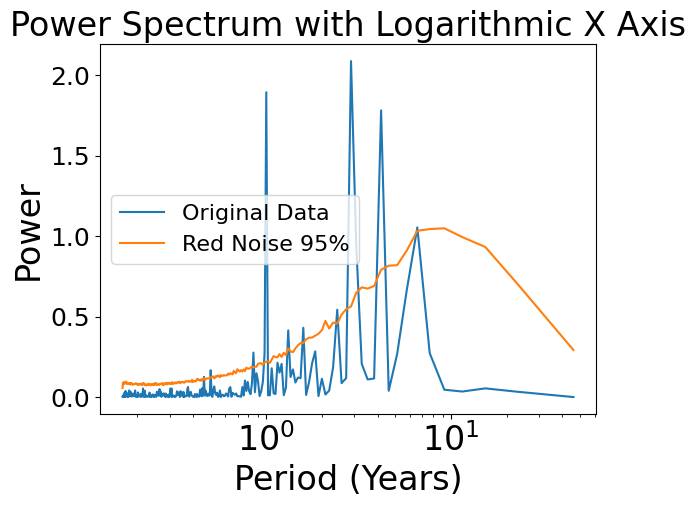

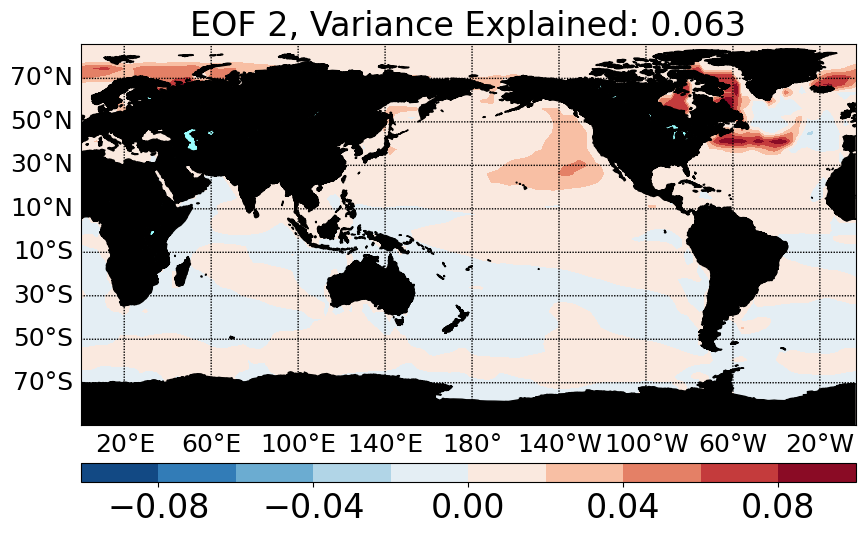

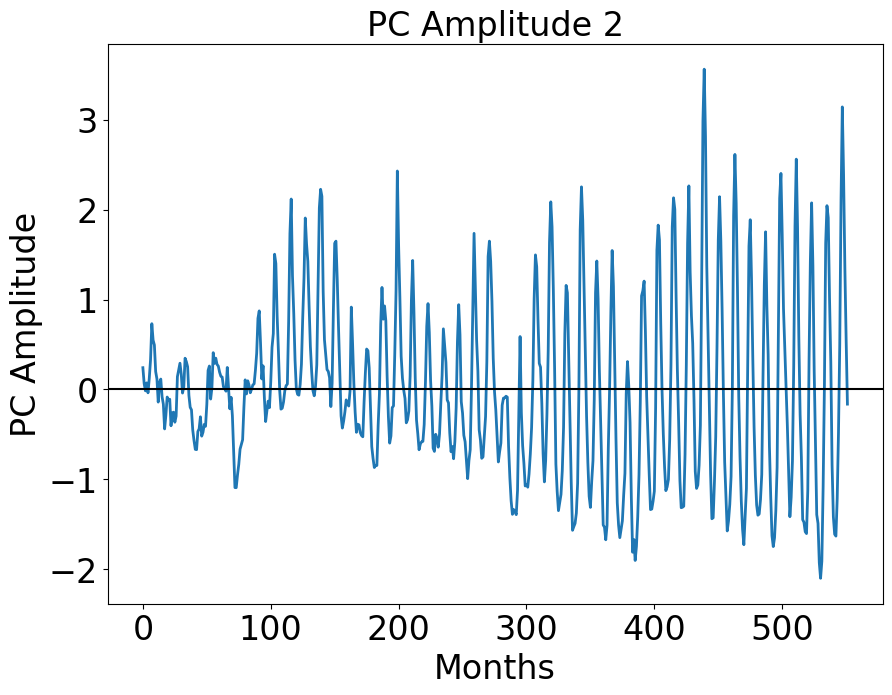

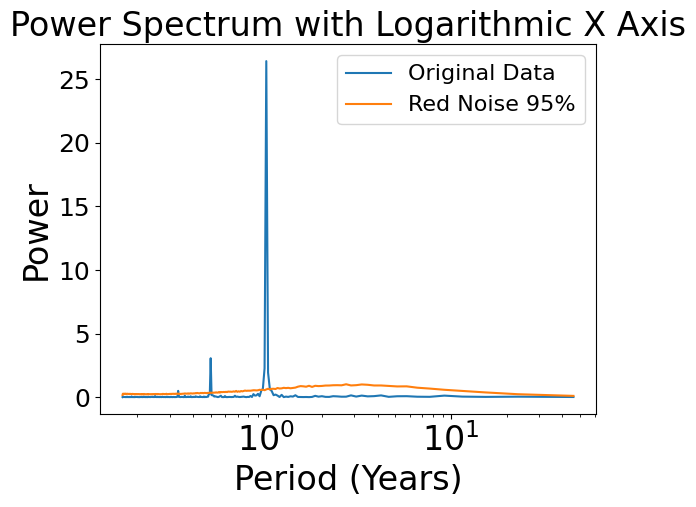

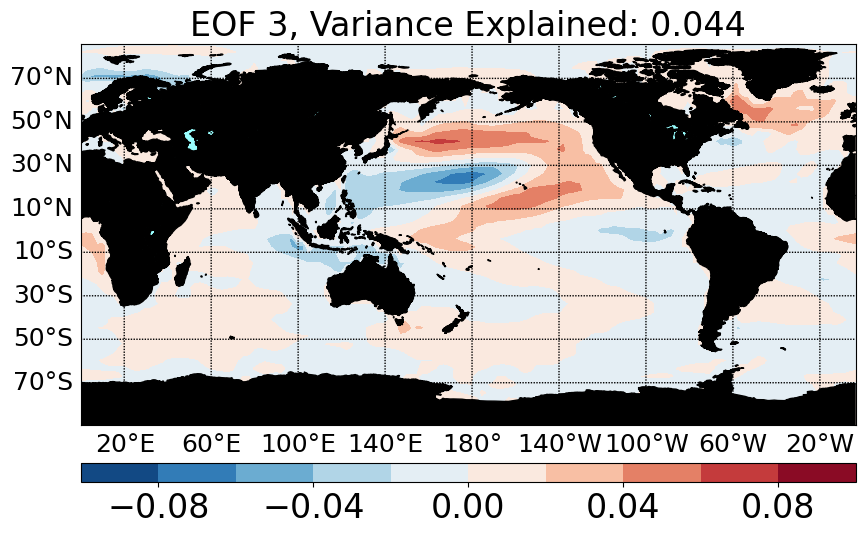

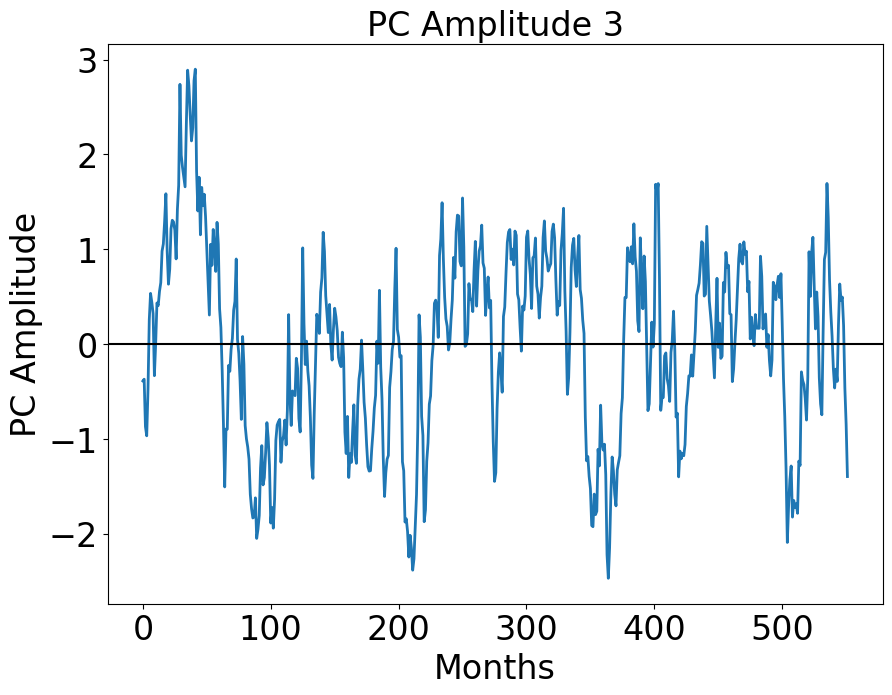

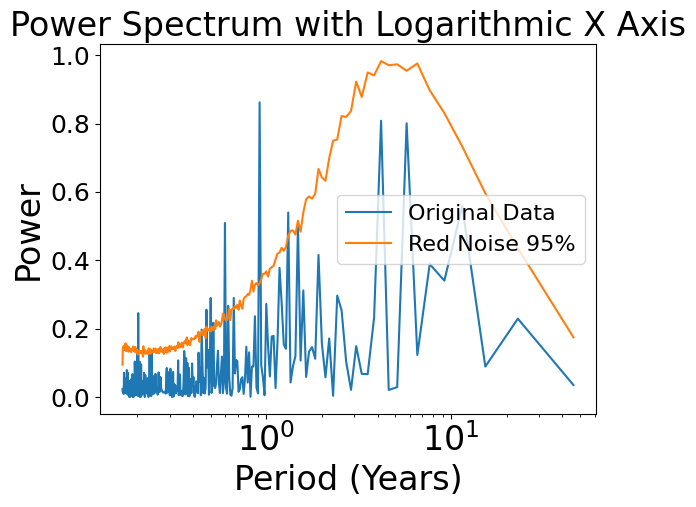

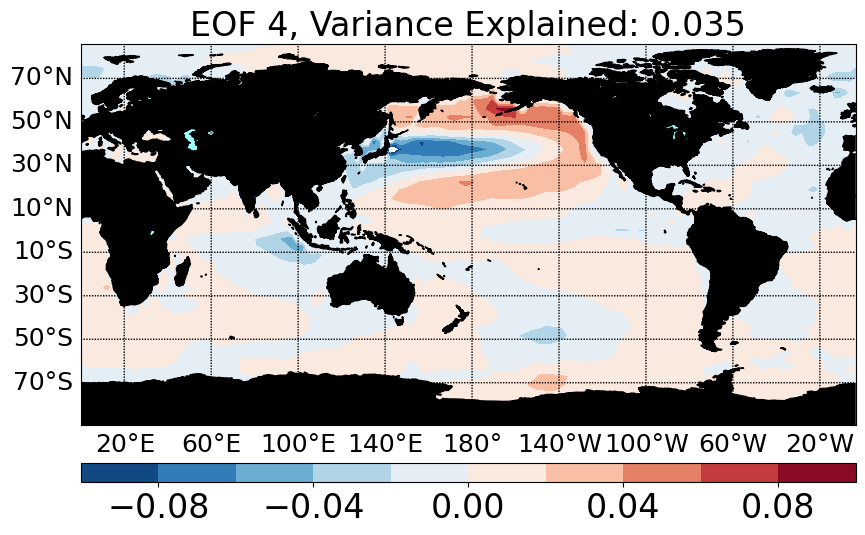

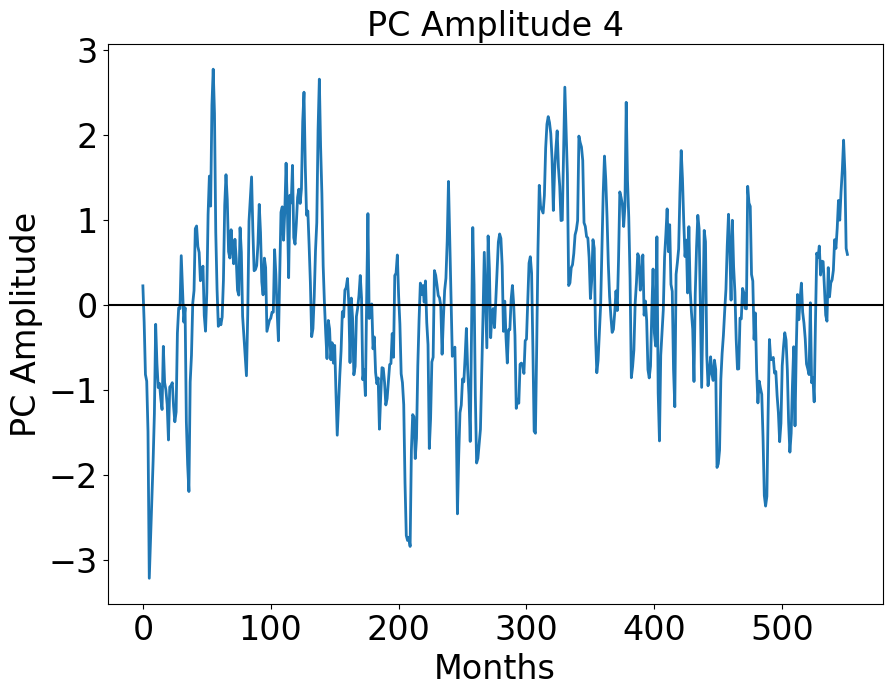

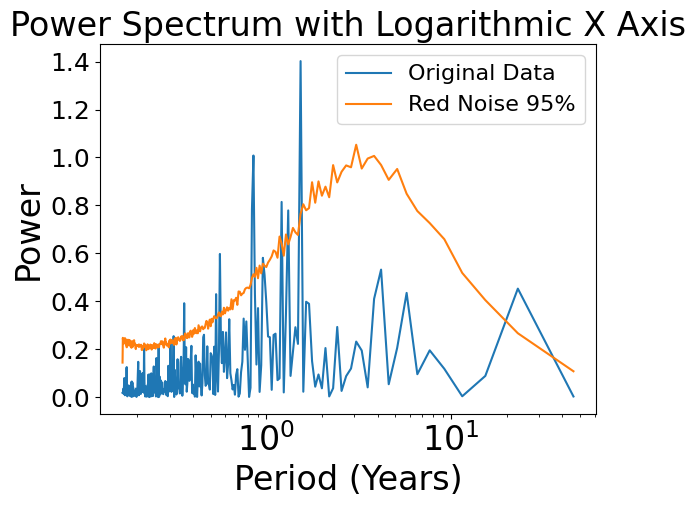

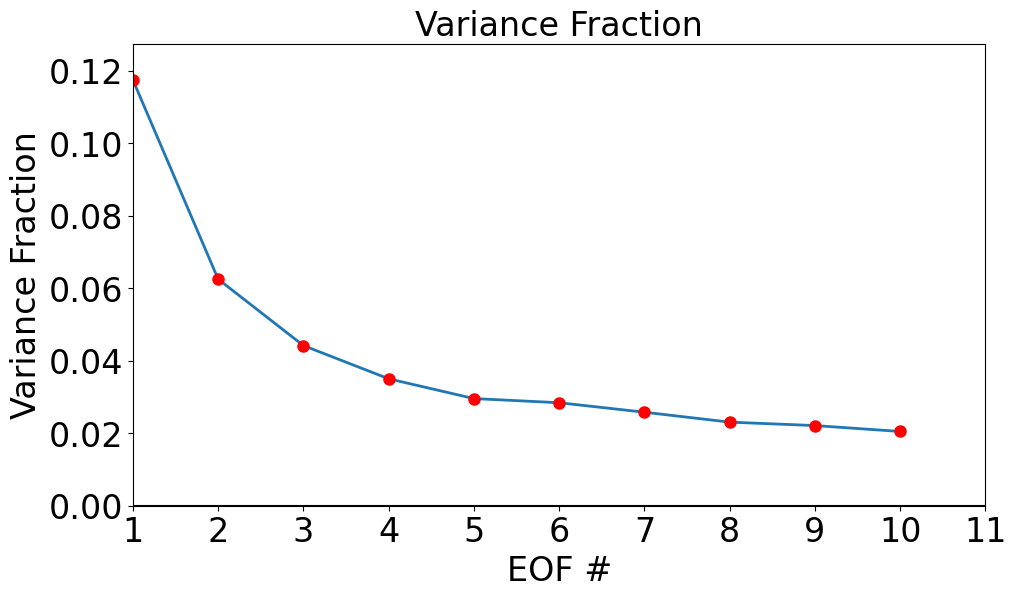

In [28]:
from eofs.standard import Eof
print('test data')
lat = lat_sst
lon = lon_sst

# Remove all time steps where all values are NaN
sst_data = test_data_norm_detrend.reshape(-1,12,48,144) - climatology 
sst_data = sst_data.reshape(-1,48,144) # shape: (time, lat, lon)
# Find time indices where not all values are NaN
valid_time_idx = ~np.all(np.isnan(sst_data), axis=(1, 2))
Data = sst_data[valid_time_idx]

wgts = np.cos(np.deg2rad(lat)).reshape(len(lat), 1)
coslat = np.cos(np.deg2rad(lat))
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(Data, weights=wgts)
eof1 = solver.eofs()

pc=solver.pcs(pcscaling=1)
varfrac=solver.varianceFraction()
lambdas=solver.eigenvalues()


parallels = np.arange(-90,90,20)
meridians = np.arange(-180,180,40)



for i in range(4):
    fig=plt.figure(figsize=(10,16)) 

    m=Basemap(projection='cyl', llcrnrlon=min(lon), llcrnrlat=min(lat),
            urcrnrlon=max(lon), urcrnrlat=max(lat), resolution='l')
    x, y = m(*np.meshgrid(lon,lat))
    clevs = np.linspace(-0.1,0.1,11)
    cs = m.contourf(x,y,eof1[i,:,:].squeeze(),clevs,cmap=plt.cm.RdBu_r)
    m.drawcoastlines()
    m.fillcontinents(color='#000000',lake_color='#99ffff')
    
    m.drawparallels(parallels,labels=[1,0,0,0], fontsize=18)
    m.drawmeridians(meridians,labels=[1,0,0,1], fontsize=18)

    cb=m.colorbar(cs, 'bottom', size='5%',pad='10%')
    cb.ax.tick_params(labelsize=24)  # Increase font size of colorbar ticks
    #cb.set_label('EOF', fontsize=10)
    plt.title('EOF '+str(i+1)+', Variance Explained: '+str(round(varfrac[i],3)), fontsize=24)  
    plt.savefig('temp.png',dpi=300,bbox_inches='tight')
    plt.show()
    fig=plt.figure(figsize=(10,16))
    plt.subplot(212)
    #days = pd.date_range('1871-01-01', '2011-01-01', freq='ME')
    plt.plot( pc[:,i], linewidth=2)
    plt.axhline(0, color='k')
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    plt.xlabel('Months', fontsize=24)
    plt.ylabel('PC Amplitude', fontsize=24) 
    plt.title('PC Amplitude '+str(i+1), fontsize=24)    
    plt.savefig('temp.png',dpi=300,bbox_inches='tight')
    plt.show()

    plot=cal_power_spect(pc[:,i])
    plt.plot(plot[:, 0]/ 12, plot[:, 1], label='Original Data')
    plt.plot(plot[:, 0]/ 12, plot[:, 2], label='Red Noise 95%')
    plt.xscale('log')
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=18)
    plt.xlabel('Period (Years)', fontsize=24)
    plt.ylabel('Power', fontsize=24)
    plt.legend(fontsize=16)
    plt.title('Power Spectrum with Logarithmic X Axis', fontsize=24)
    plt.savefig('temp.png',dpi=300,bbox_inches='tight')
    plt.show()

plt.figure(figsize=(11,6))
eof_num = range(1, 11)
plt.plot(eof_num, varfrac[0:10], linewidth=2)
plt.plot(eof_num, varfrac[0:10], linestyle='None', marker="o", color='r', markersize=8)
plt.axhline(0, color='k')
plt.xticks(range(1, 16),fontsize=24)
plt.yticks(fontsize=24)
plt.title('Fraction of the total variance represented by each EOF', fontsize=15)
plt.xlabel('EOF #', fontsize=24)
plt.ylabel('Variance Fraction', fontsize=24)
plt.xlim(1, 11)
plt.ylim(np.min(varfrac), np.max(varfrac)+0.01)
plt.title('Variance Fraction', fontsize=24)  
plt.savefig('temp.png',dpi=300,bbox_inches='tight')
plt.show()

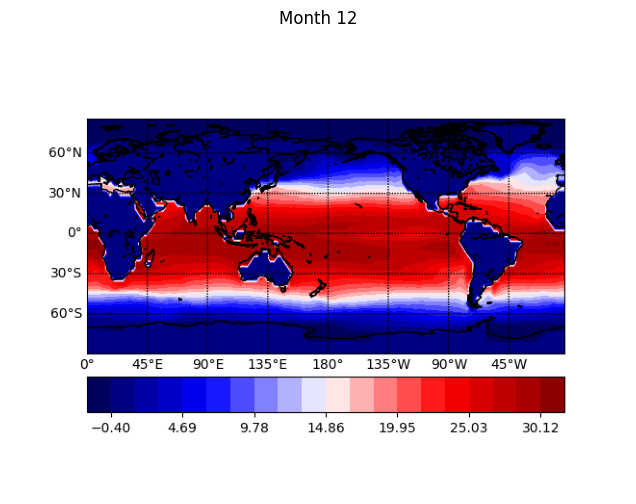

In [9]:
from PIL import Image
import os

import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Create a list to store image filenames
image_files = []
for i in range(12):
    image_path = f'../../Data/output/Temp/seasonal_pattern{i+1}.png'
    if os.path.exists(image_path):
        image_files.append(image_path)

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Function to update animation
def update(frame):
    ax.clear()
    img = Image.open(image_files[frame])
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Month {frame + 1}')

# Create animation
ani = animation.FuncAnimation(fig, update, frames=len(image_files), repeat=True, interval=500)

# Save or display animation
ani.save('../../Data/output/GISS/Updated/seasonal_animation.gif', writer='pillow')
plt.show()